# 2. PSF modeling and subtraction

In this notebook, we demonstrate the PSF modeling and subtraction tools in coronspec_tools. We're going to use the offset files with the incidental source in the slit.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

In [3]:
import matplotlib as mpl
from matplotlib import pyplot as plt

In [4]:
from coronspec_tools import utils as ctutils
from coronspec_tools import misc as ctmisc

In [5]:
from astropy import units

## List and organize the data files

I like to use a Pandas dataframe to organize my data files by metadata. Since all data files of the same type (e.g. sx1, sx2, flt, et cetera) have the same header keywords, they fit neatly into a dataframe format where the columns represent the keyword value and each row is a separate file. `coronspec_tools.utils` has some functions for setting this up.

In [6]:
# First, let's list all the data files available. Set your path as appropriate.
data_files = sorted(Path("../../data/MAST_2024-03-21T13_06_42.642Z/MAST_2024-03-21T13_06_42.642Z/HST/").glob("OF*/*fits"))

In [7]:
# for each file type, let's make a separate "file manager" dataframe using utils.organize_files_by_header(list_of_files)
file_managers = {}
for f in data_files:
    ftype = f.stem.split("_")[1]
    if ftype not in file_managers.keys():
        file_managers[ftype] = []
    file_managers[ftype].append(f)
for ft in file_managers:
    file_managers[ft] = ctutils.organize_files_by_header(file_managers[ft])

In [8]:
# we need the sx1 file, the unocculted exposure, and the occulted exposure. Looking at the Data Spreadsheet, these are:
sx1_rootname = 'OF0I02010'.lower()
unocc_rootname = 'OF0I02010'.lower()
occ_rootname = 'OF0I02020'.lower()

# the sx1 file is in the sx1 file manager:
sx1_file = file_managers['sx1'].set_index("ROOTNAME").loc[sx1_rootname]['filepath']
# we're going to use the _un_rectified 2-D spectral images
unocc_file = file_managers['crj'].set_index("ROOTNAME").loc[unocc_rootname]['filepath']
occ_file = file_managers['crj'].set_index("ROOTNAME").loc[occ_rootname]['filepath']

In [74]:
from coronspec_tools import observing_sequence
obs = observing_sequence.ObsSeq(
    sx1_file=sx1_file,
    unocc_file=unocc_file,
    occ_file=occ_file,
    trace_width = 11, # cut out a stamp of this width in rows around the unocculted trace
    occ_stamp_width = 101, # cut a stamp of this width in rows around the occulted star position
    median_clean = 10, # apply a median filter of 2x this width in columns to smooth bad pixels
    contrast = True, # if True, divide by the unocculted spectrum to work in units of contrast
)

In [75]:
from coronspec_tools import sdi_tools, retrieval_tools

## SDI class

Let's examine row 71 in the stamp, the approximate position of the contaminant. We will look at the signal in row 85 of the scaled stamp.

In [124]:
sdi = sdi_tools.SDI(obs, psf_halfwidth=8)
sdi.ref_wl_ind = int(sdi.obs.wlsol.size/2)

## Retriever class

In [125]:
from coronspec_tools import retrieval_tools

In [126]:
ret = retrieval_tools.Retriever(sdi)

In [127]:
flat_trace = ret.flatten_trace()
np.median(ret.obs.unocc_trace.data), np.median(flat_trace)

(np.float64(1.2828783857501245), np.float64(1.1251309523627118))

Plot the old and new traces together to make sure the scales make sense

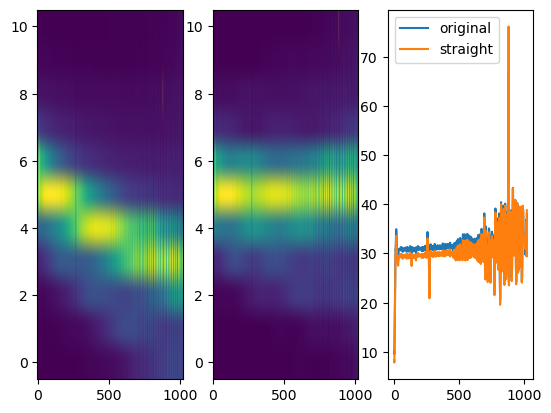

In [128]:
fig, axes = plt.subplots(nrows=1, ncols=3)
ax  = axes[0]
vrange = ctmisc.img_vrange(obs.unocc_trace.data)
ax.imshow(obs.unocc_trace.data, aspect='auto', origin='lower', **vrange)
ax = axes[1]
ax.imshow(flat_trace, aspect='auto', origin='lower', **vrange)
ax = axes[2]
ax.plot(obs.unocc_trace.data.sum(axis=0), label='original', c='C0')
ax.plot(flat_trace.sum(axis=0), label='straight', c='C1')
ax.legend()

Close enough for jazz! Let's assign this to the `ret` object

In [130]:
ret.trace = flat_trace